# Мультимодальный поиск (Text-to-Image) с использованием CLIP и Qdrant

Этот ноутбук реализует систему поиска изображений по текстовому описанию.

**Стек:**
- **Модель:** CLIP (openai/clip-vit-base-patch32)
- **Векторная БД:** Qdrant (в Docker)
- **Датасет:** Conceptual Captions (валидационная выборка)
- **Процесс:** Загрузка датасета -> Скачивание изображений -> Генерация эмбеддингов -> Индексация -> Поиск

In [15]:
!pip install -r ../requirements.txt

In [16]:
import os
import requests
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm
import torch
from transformers import CLIPProcessor, CLIPModel
from qdrant_client import QdrantClient
from qdrant_client.http import models
from datasets import load_dataset
import matplotlib.pyplot as plt

# Конфигурация
DATA_DIR = "../data/images"
COLLECTION_NAME = "multimodal_gallery"
MODEL_ID = "openai/clip-vit-base-patch32"
QDRANT_HOST = "localhost"
QDRANT_PORT = 6333
SAMPLE_SIZE = 500  # Ограничим для демонстрации (установите None для полной загрузки)

os.makedirs(DATA_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Подготовка данных
Загружаем валидационную часть датасета Conceptual Captions и скачиваем изображения локально.

In [17]:
dataset = load_dataset("google-research-datasets/conceptual_captions", split="validation", trust_remote_code=True)

# Берем подмножество
if SAMPLE_SIZE:
    dataset = dataset.select(range(SAMPLE_SIZE))

print(f"Dataset size: {len(dataset)}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google-research-datasets/conceptual_captions' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Dataset size: 500


In [18]:
def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert("RGB")
        image.save(save_path)
        return True
    except Exception:
        return False

valid_images = []

print("Downloading images...")
for idx, item in tqdm(enumerate(dataset), total=len(dataset)):
    image_url = item['image_url']
    caption = item['caption']
    image_filename = f"{idx}.jpg"
    image_path = os.path.join(DATA_DIR, image_filename)

    # Проверяем, скачано ли уже
    if os.path.exists(image_path):
        valid_images.append({"id": idx, "path": image_path, "caption": caption})
        continue

    if download_image(image_url, image_path):
        valid_images.append({"id": idx, "path": image_path, "caption": caption})

print(f"Successfully downloaded: {len(valid_images)} images")

  0%|          | 0/500 [00:00<?, ?it/s]

Successfully downloaded: 201 images


## 2. Инициализация Модели и Векторной БД

In [19]:
model = CLIPModel.from_pretrained(MODEL_ID).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_ID)

# Инициализация клиента Qdrant
client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)

# Создание коллекции, если не существует
collections = client.get_collections()
collection_names = [c.name for c in collections.collections]

if COLLECTION_NAME not in collection_names:
    client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=models.VectorParams(size=512, distance=models.Distance.COSINE),
    )
    print(f"Collection '{COLLECTION_NAME}' created.")
else:
    print(f"Collection '{COLLECTION_NAME}' already exists.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Collection 'multimodal_gallery' already exists.


## 3. Генерация эмбеддингов и индексация
Проходим по всем скачанным изображениям, векторизуем их и отправляем в Qdrant.

In [20]:
def get_image_embedding(image_path):
    try:
        image = Image.open(image_path)
        inputs = processor(images=image, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            image_features = model.get_image_features(**inputs)
        
        # Fix for transformers returning BaseModelOutputWithPooling
        if hasattr(image_features, 'pooler_output'):
            image_features = image_features.pooler_output

        # Нормализация не обязательна для Cosine, но полезна
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        return image_features.cpu().numpy()[0].tolist()
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

points = []
print("Indexing images...")

for item in tqdm(valid_images):
    vector = get_image_embedding(item['path'])
    if vector:
        points.append(models.PointStruct(
            id=item['id'],
            vector=vector,
            payload={
                "path": item['path'],
                "caption": item['caption']
            }
        ))

# Загрузка батчами для оптимизации
BATCH_SIZE = 100
for i in range(0, len(points), BATCH_SIZE):
    batch = points[i:i + BATCH_SIZE]
    client.upsert(
        collection_name=COLLECTION_NAME,
        points=batch
    )

print(f"Indexed {len(points)} images into Qdrant.")

Indexing images...


  0%|          | 0/201 [00:00<?, ?it/s]

Indexed 201 images into Qdrant.


## 4. Реализация поиска (Text-to-Image)
Функция, которая принимает текст, векторизует его и ищет ближайшие изображения в БД.

In [21]:
def search_images(query_text, top_k=3):
    # Векторизация запроса
    inputs = processor(text=[query_text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
    
    # Fix for transformers returning BaseModelOutputWithPooling
    if hasattr(text_features, 'pooler_output'):
        text_features = text_features.pooler_output
    
    text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
    query_vector = text_features.cpu().numpy()[0].tolist()

    # Поиск в Qdrant
    # Используем `query_points` вместо `search` т.к. `search` отсутствует в данной версии
    search_result_obj = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        limit=top_k
    )
    search_result = search_result_obj.points

    # Отображение результатов
    plt.figure(figsize=(15, 5))
    for i, file in enumerate(search_result):
        path = file.payload['path']
        caption = file.payload['caption']
        score = file.score
        
        try:
            img = Image.open(path)
            plt.subplot(1, top_k, i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Score: {score:.3f}\n{caption[:30]}...")
        except FileNotFoundError:
            print(f"Warning: Image not found at {path}")
            
    plt.suptitle(f"Query: '{query_text}'", fontsize=16)
    plt.show()

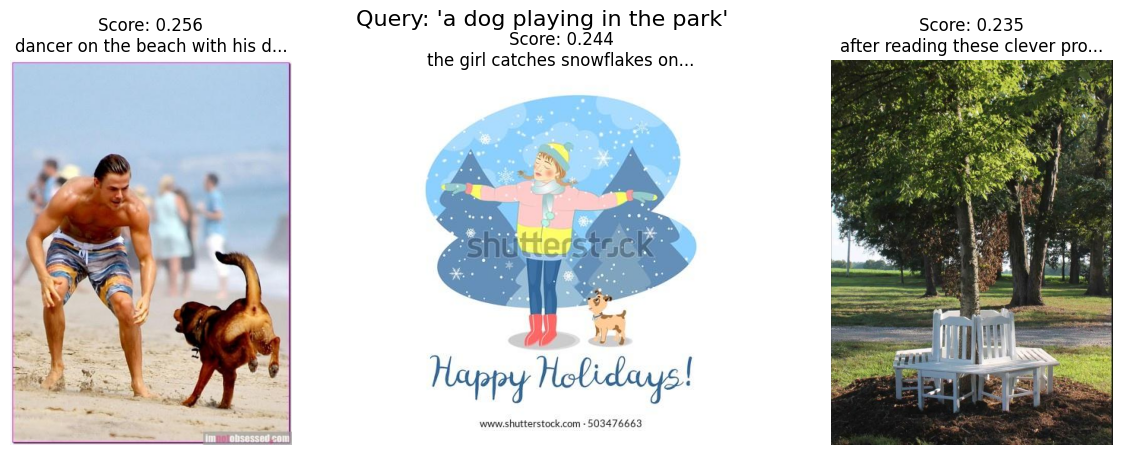

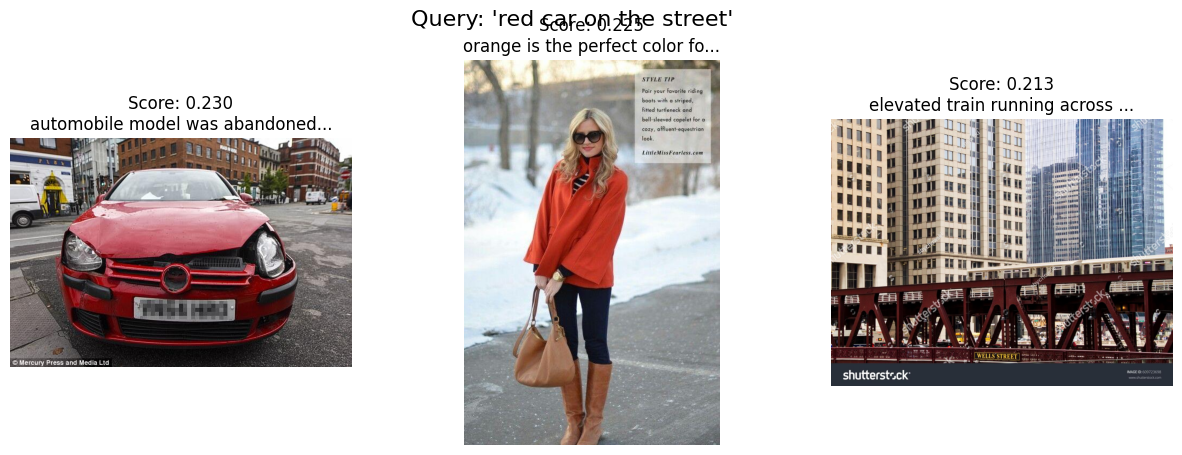

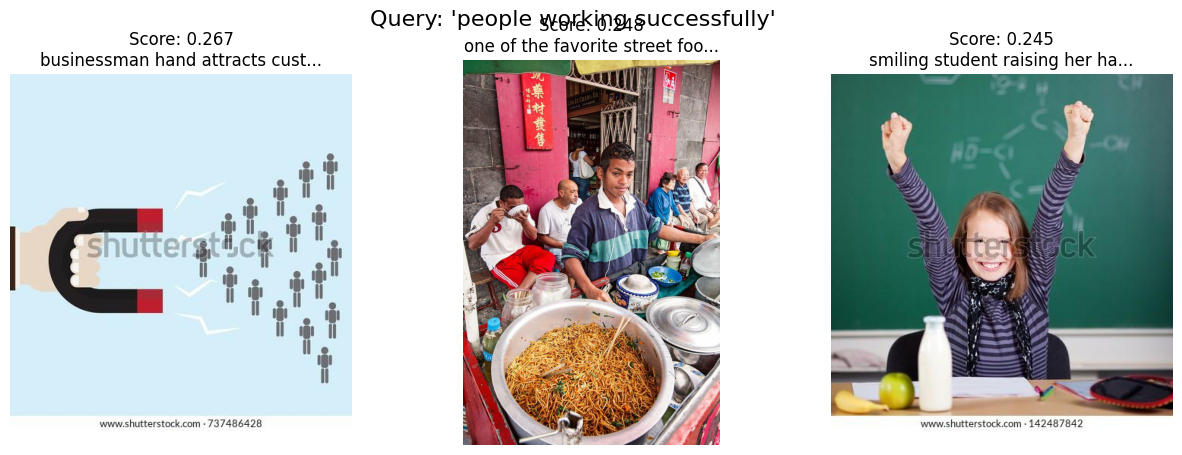

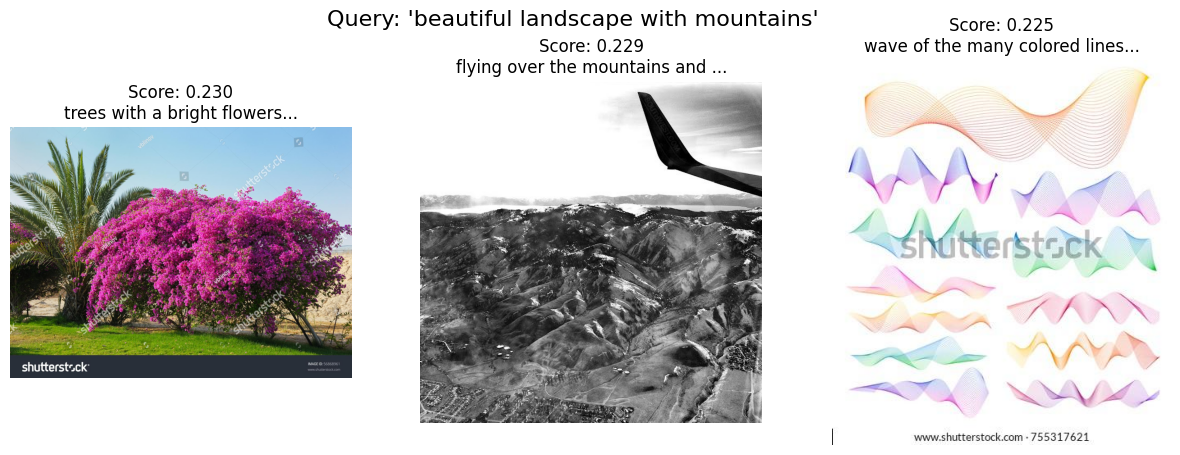

In [22]:
# Тестовые запросы
queries = [
    "a dog playing in the park",
    "red car on the street",
    "people working successfully", 
    "beautiful landscape with mountains"
]

for q in queries:
    search_images(q)

## 5. Оценка качества (Evaluation)
Простой Recall@K тест, использующий caption изображения как поисковый запрос. Если изображение найдено в топ-K выдаче по своему же описанию – это успех.

In [23]:
def evaluate_recall_at_k(k=5, num_samples=50):
    correct_matches = 0
    test_samples = valid_images[:num_samples] if len(valid_images) > num_samples else valid_images
    
    for item in tqdm(test_samples, desc="Evaluating"):
        query_text = item['caption']
        target_id = item['id']
        
        # Векторизация
        inputs = processor(text=[query_text], return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            text_features = model.get_text_features(**inputs)
        
        # Fix for transformers returning BaseModelOutputWithPooling
        if hasattr(text_features, 'pooler_output'):
            text_features = text_features.pooler_output
            
        text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
        query_vector = text_features.cpu().numpy()[0].tolist()
        
        # Поиск
        results_obj = client.query_points(
            collection_name=COLLECTION_NAME,
            query=query_vector,
            limit=k
        )
        results = results_obj.points
        
        # Проверка
        found_ids = [res.id for res in results]
        if target_id in found_ids:
            correct_matches += 1
            
    recall = correct_matches / len(test_samples)
    return recall

recall_score = evaluate_recall_at_k(k=5)
print(f"Recall@5: {recall_score:.2f}")

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Recall@5: 0.94
